## 01-Analisis imploratorio de datos (EDA)

En este notebook se realiza el análisis exploratorio inicial del dataset de ventas utilizado en el proyecto de predicción de riesgo de rotura de stock.

El objetivo es identificar patrones relevantes para el problema logístico:

- Evolución temporal de las ventas.
- Estacionalidad mensual y semanal.
- Diferencias entre tiendas y productos.
- Efecto de las promociones.
- Variabilidad de la demanda.
- Relación entre ventas, precio y promoción.

## 1. Importación de librerías y configuración inicial

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FIGURES_PATH = "../outputs/figures/eda"

sns.set_theme(style="whitegrid")

## 2. Carga del dataset

In [2]:
df = pd.read_csv("../data/raw/retail_sales.csv")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()
df.shape

Filas: 4,565,000
Columnas: 8


(4565000, 8)

## 3. Revision inicial de estructura y calidad de datos

En esta sección se revisa la estructura básica del dataset: tipos de datos, nulos, duplicados y columnas disponibles.

Esto permite detectar problemas antes de realizar análisis temporales o construir variables para el modelo.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      str    
 1   store_id  str    
 2   item_id   str    
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 278.6 MB


In [4]:
pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
}).sort_values("missing_pct", ascending=False)

,column,dtype,missing_values,missing_pct,unique_values
0,date,str,0,0.00,1826
1,store_id,str,0,0.00,50
2,item_id,str,0,0.00,50
3,sales,int64,0,0.00,139
4,price,float64,0,0.00,3798
5,promo,int64,0,0.00,2
6,weekday,int64,0,0.00,7
7,month,int64,0,0.00,12


In [5]:
duplicated_rows = df.duplicated().sum()
print(f"Filas duplicadas: {duplicated_rows:,}")

Filas duplicadas: 0


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,4565000,1826,2019-01-01,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,4565000,50,store_1,91300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,4565000,50,item_1,91300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,"4,565,000.00",NaN,NaN,NaN,29.26,15.01,0.00,18.00,27.00,38.00,139.00
price,"4,565,000.00",NaN,NaN,NaN,53.99,25.78,8.02,31.97,53.52,75.36,99.99
promo,"4,565,000.00",NaN,NaN,NaN,0.10,0.30,0.00,0.00,0.00,0.00,1.00
weekday,"4,565,000.00",NaN,NaN,NaN,3.00,2.00,0.00,1.00,3.00,5.00,6.00
month,"4,565,000.00",NaN,NaN,NaN,6.52,3.45,1.00,4.00,7.00,10.00,12.00


## 4. Preparación mínima para el análisis temporal

Se convierte la columna de fecha a tipo `datetime` y se crean variables temporales auxiliares para analizar patrones por año, mes, semana y día de la semana.

Estas variables se utilizarán únicamente para análisis exploratorio. 

In [7]:
# Comprobación de columnas mínimas esperadas
required_columns = ["date", "store_id", "item_id", "sales", "price", "promo"]
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Faltan columnas necesarias para este EDA: {missing_required}")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M").astype(str)
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["weekday"] = df["date"].dt.dayofweek
df["weekday_name"] = df["date"].dt.day_name()

print(f"Rango temporal: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"Nº tiendas: {df['store_id'].nunique():,}")
print(f"Nº productos: {df['item_id'].nunique():,}")

Rango temporal: 2019-01-01 a 2023-12-31
Nº tiendas: 50
Nº productos: 50


## 5. Ventas por fecha

In [8]:
daily_sales = (
    df.groupby("date", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          avg_sales=("sales", "mean"),
          transactions=("sales", "count"),
          avg_price=("price", "mean"),
          promo_rate=("promo", "mean")
      )
)

daily_sales.head()

,date,total_sales,avg_sales,transactions,avg_price,promo_rate
0,2019-01-01,74119,29.65,2500,53.97,0.10
1,2019-01-02,77119,30.85,2500,53.97,0.10
2,2019-01-03,70810,28.32,2500,53.89,0.11
3,2019-01-04,59269,23.71,2500,54.04,0.09
4,2019-01-05,52621,21.05,2500,53.95,0.10


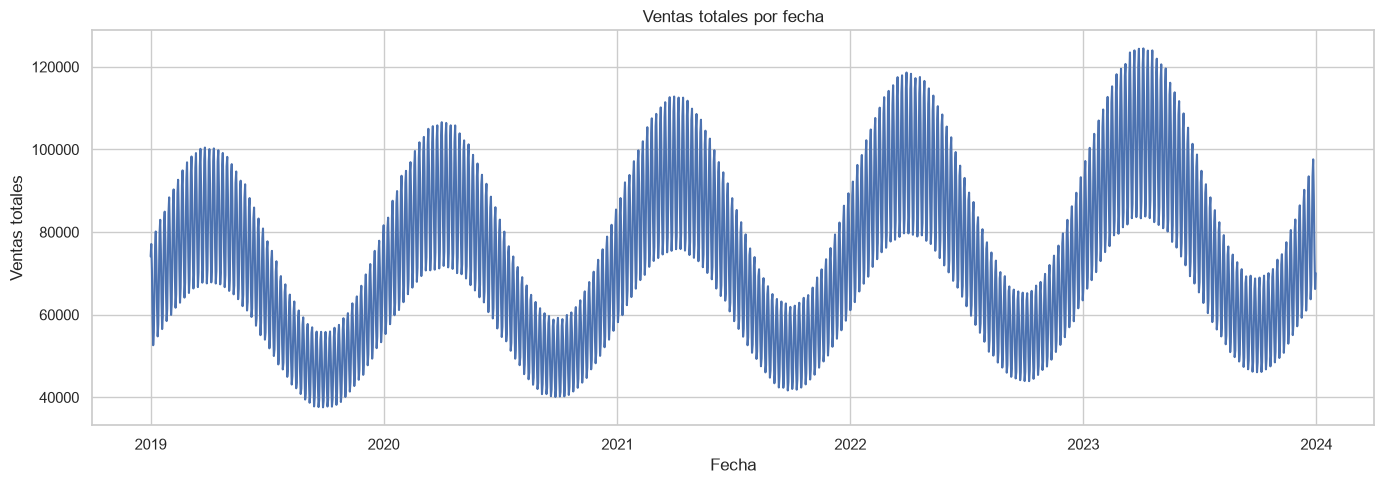

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["total_sales"])
plt.title("Ventas totales por fecha")
plt.xlabel("Fecha")
plt.ylabel("Ventas totales")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/ventas_totales_por_fecha.png", dpi=150)
plt.show()

### Explicación

Este gráfico permite identificar si existen tendencias generales, cambios bruscos, picos de demanda o periodos con menor actividad.  
En un problema de stockout, los picos de ventas son especialmente relevantes porque pueden anticipar situaciones de desabastecimiento si no existe stock suficiente.

## 6. Evolución temporal de ventas con media móvil

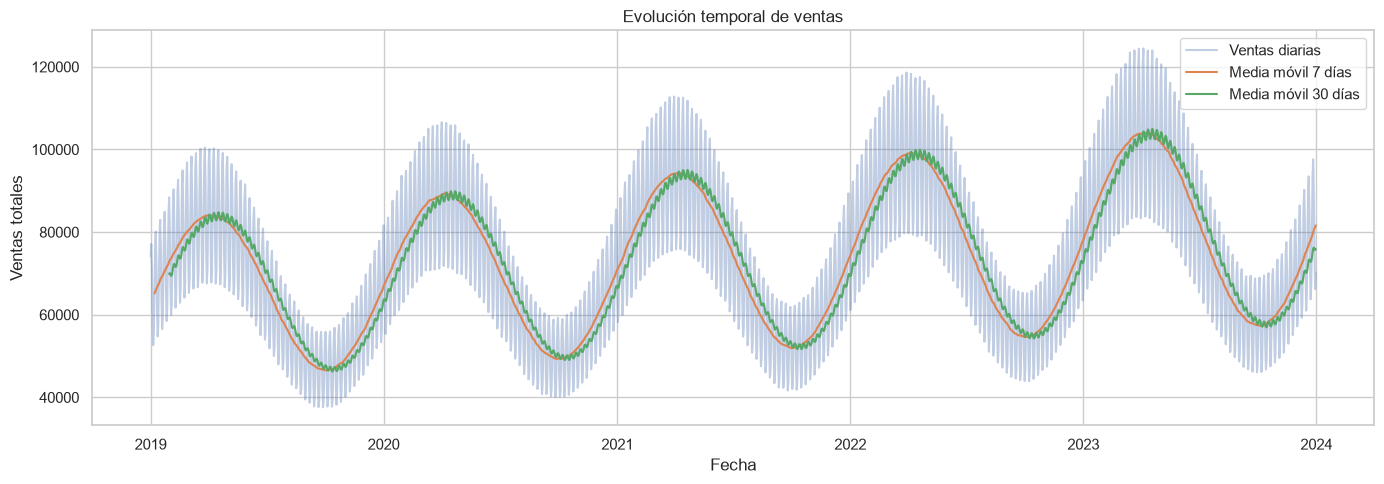

In [13]:
daily_sales["rolling_mean_7"] = daily_sales["total_sales"].rolling(window=7).mean()
daily_sales["rolling_mean_30"] = daily_sales["total_sales"].rolling(window=30).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["total_sales"], alpha=0.35, label="Ventas diarias")
plt.plot(daily_sales["date"], daily_sales["rolling_mean_7"], label="Media móvil 7 días")
plt.plot(daily_sales["date"], daily_sales["rolling_mean_30"], label="Media móvil 30 días")
plt.title("Evolución temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas totales")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/evolucion_temporal_ventas_media_movil.png", dpi=150)
plt.show()

### Explicación

La media móvil reduce el ruido diario y ayuda a observar tendencias.  
Si la media de 7 días supera de forma recurrente a la de 30 días, puede indicar aumentos recientes de demanda que deberían considerarse en la generación de variables del modelo.

## 7. Ventas medias por mes

In [14]:
monthly_sales = (
    df.groupby("month", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          avg_sales=("sales", "mean"),
          observations=("sales", "count")
      )
)

monthly_sales

,month,total_sales,avg_sales,observations
0,1,11979500,30.91,387500
1,2,12245307,34.74,352500
2,3,14440823,37.27,387500
3,4,13981258,37.28,375000
4,5,13678035,35.30,387500
5,6,11883299,31.69,375000
6,7,10511655,27.13,387500
7,8,9063043,23.39,387500
8,9,7939706,21.17,375000
9,10,8202347,21.17,387500


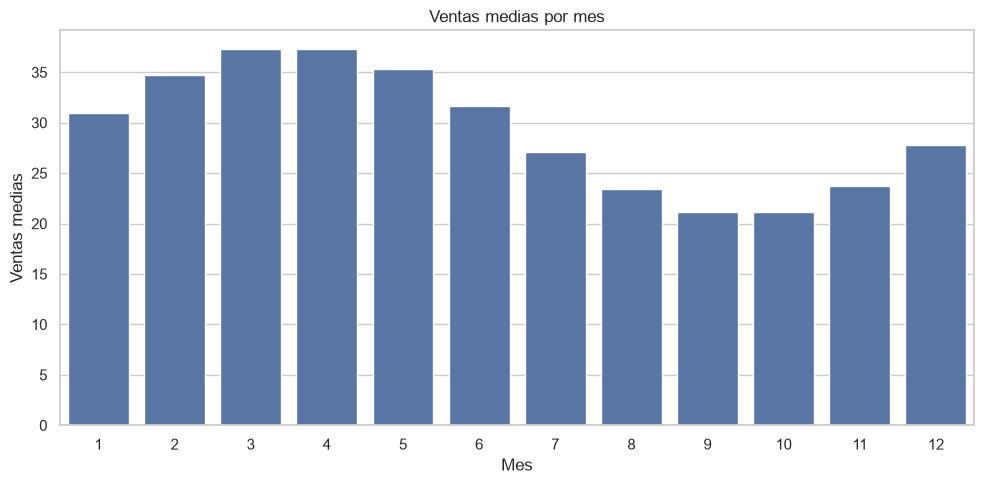

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_sales, x="month", y="avg_sales")
plt.title("Ventas medias por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas medias")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/ventas_medias_por_mes.png", dpi=150)
plt.show()

## 8. Ventas medias por día de la semana

In [16]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_sales = (
    df.groupby(["weekday", "weekday_name"], as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          avg_sales=("sales", "mean"),
          observations=("sales", "count")
      )
      .sort_values("weekday")
)

weekday_sales

,weekday,weekday_name,total_sales,avg_sales,observations
0,0,Monday,19019946,29.26,650000
1,1,Tuesday,22074659,33.83,652500
2,2,Wednesday,22819928,34.97,652500
3,3,Thursday,20751986,31.80,652500
4,4,Friday,17437010,26.72,652500
5,5,Saturday,15378915,23.57,652500
6,6,Sunday,16110730,24.69,652500


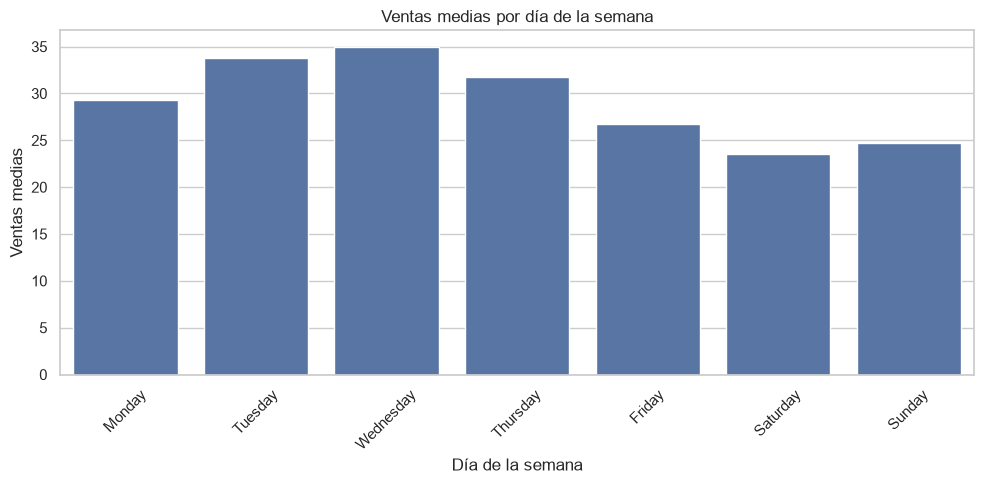

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=weekday_sales, x="weekday_name", y="avg_sales", order=weekday_order)
plt.title("Ventas medias por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Ventas medias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/ventas_medias_por_dia_semana.png", dpi=150)
plt.show()

### Explicación

Este análisis permite detectar patrones semanales.  
Si determinados días concentran mayor demanda media, la variable `weekday` puede ser útil para el modelo predictivo.

## 9. Distribución de ventas por producto

In [18]:
product_sales = (
    df.groupby("item_id", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          avg_sales=("sales", "mean"),
          std_sales=("sales", "std"),
          observations=("sales", "count")
      )
      .sort_values("total_sales", ascending=False)
)

product_sales.head(20)

,item_id,total_sales,avg_sales,std_sales,observations
12,item_20,4261507,46.68,15.27,91300
0,item_1,4207065,46.08,15.16,91300
22,item_3,4108554,45.00,14.84,91300
46,item_6,4051413,44.37,14.60,91300
33,item_4,3964580,43.42,14.31,91300
32,item_39,3938555,43.14,14.22,91300
24,item_31,3861901,42.30,13.95,91300
4,item_13,3752355,41.10,13.59,91300
16,item_24,3710934,40.65,13.43,91300
9,item_18,3665037,40.14,13.27,91300


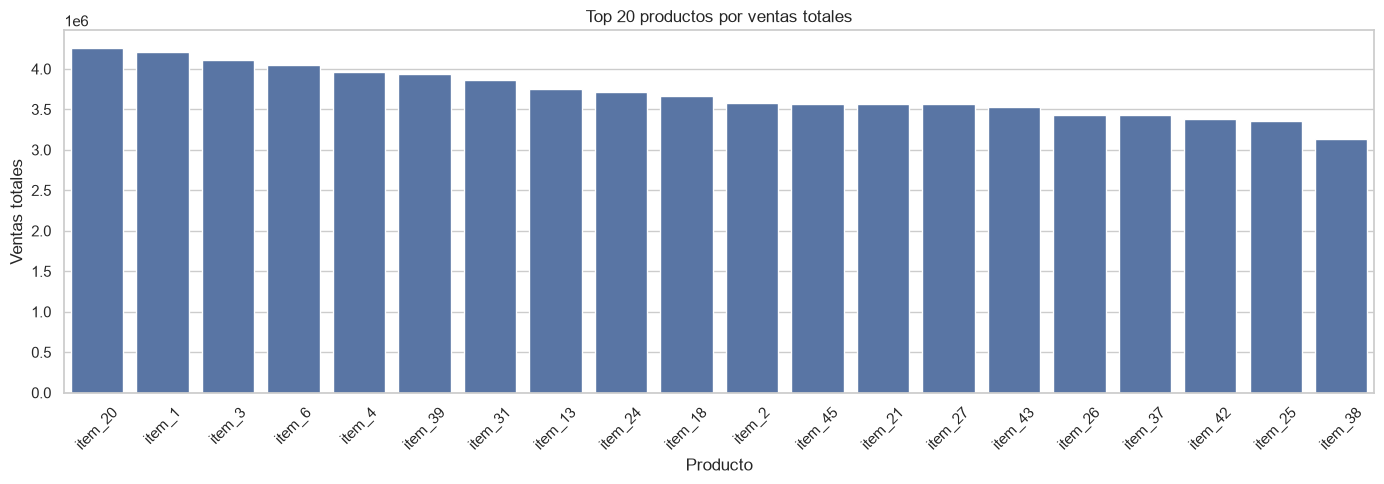

In [19]:
plt.figure(figsize=(14, 5))
sns.barplot(data=product_sales.head(20), x="item_id", y="total_sales")
plt.title("Top 20 productos por ventas totales")
plt.xlabel("Producto")
plt.ylabel("Ventas totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/top20_productos_ventas_totales.png", dpi=150)
plt.show()

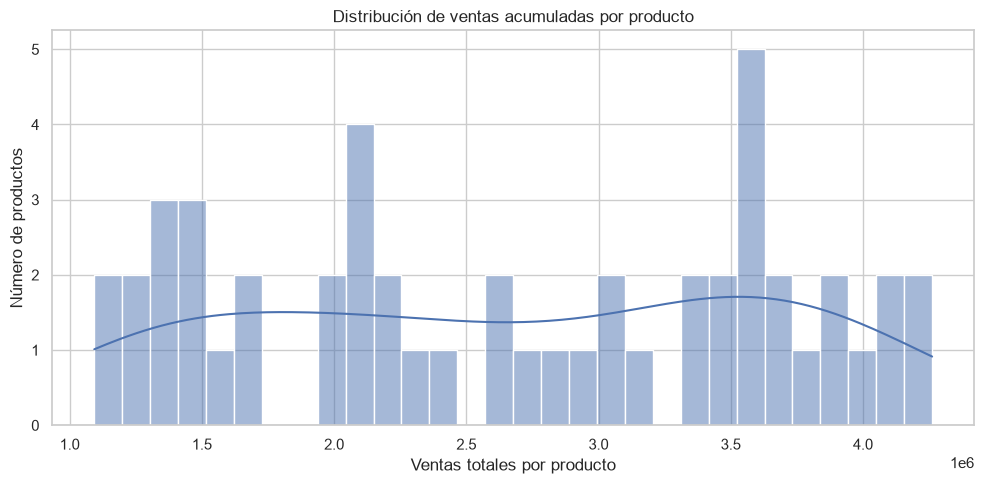

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(product_sales["total_sales"], bins=30, kde=True)
plt.title("Distribución de ventas acumuladas por producto")
plt.xlabel("Ventas totales por producto")
plt.ylabel("Número de productos")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/distribucion_ventas_por_producto.png", dpi=150)
plt.show()

### Explicación

Este análisis ayuda a identificar si la demanda está concentrada en pocos productos o si está repartida de forma homogénea.  
En logística, los productos con mayor volumen o mayor variabilidad suelen requerir mayor atención en la gestión de inventario.

## 10. Distribución de precios

In [21]:
price_summary = df["price"].describe()
price_summary

count   4,565,000.00
mean           53.99
std            25.78
min             8.02
25%            31.97
50%            53.52
75%            75.36
max            99.99
Name: price, dtype: float64

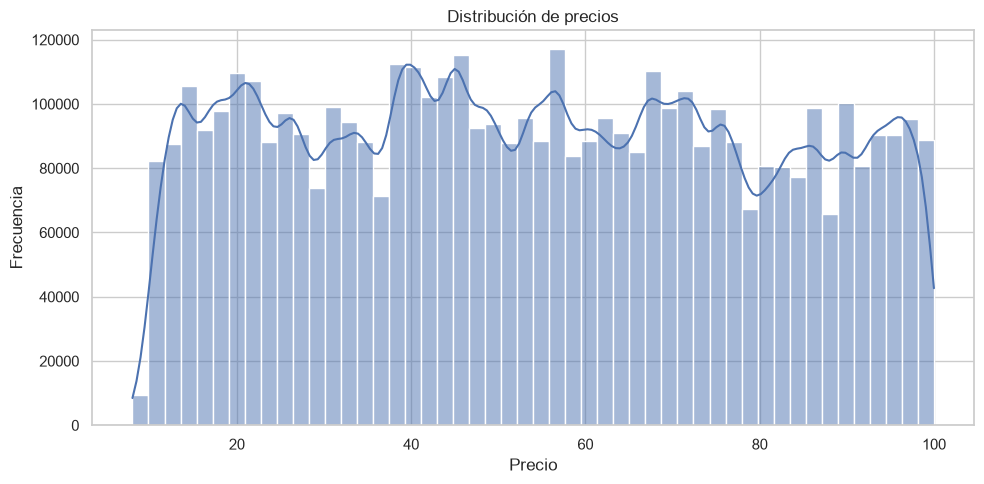

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/distribucion_precios.png", dpi=150)
plt.show()

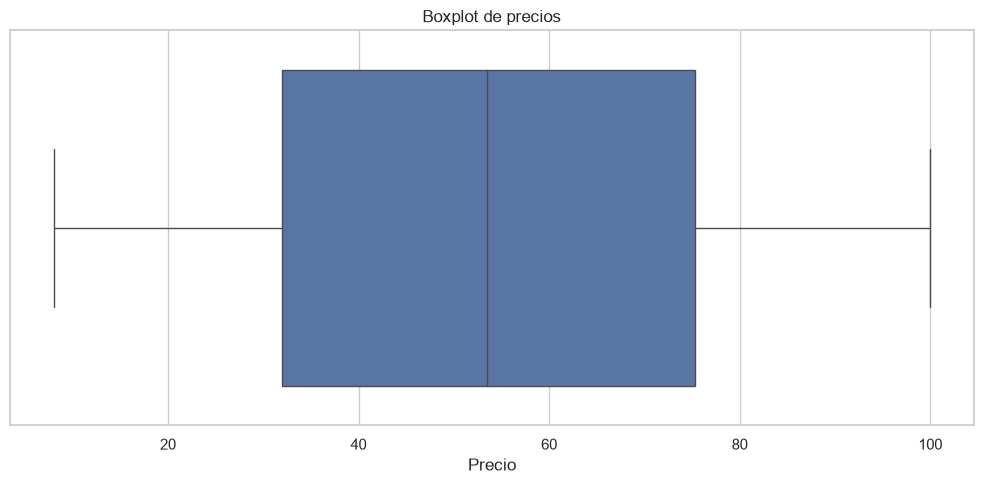

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="price")
plt.title("Boxplot de precios")
plt.xlabel("Precio")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/boxplot_precios.png", dpi=150)
plt.show()

## 11. Impacto de promociones en ventas

In [24]:
promo_sales = (
    df.groupby("promo", as_index=False)
      .agg(
          avg_sales=("sales", "mean"),
          median_sales=("sales", "median"),
          total_sales=("sales", "sum"),
          observations=("sales", "count"),
          avg_price=("price", "mean")
      )
)

promo_sales

,promo,avg_sales,median_sales,total_sales,observations,avg_price
0,0,27.86,26.00,114482812,4108506,55.09
1,1,41.86,39.00,19110362,456494,44.10


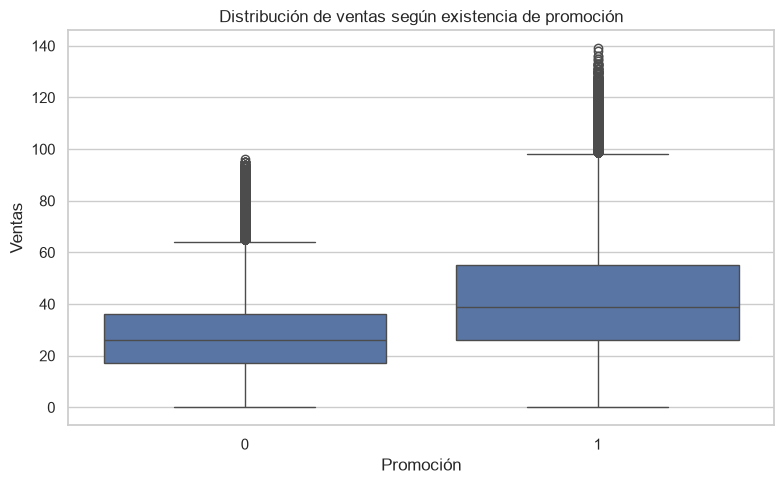

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="promo", y="sales")
plt.title("Distribución de ventas según existencia de promoción")
plt.xlabel("Promoción")
plt.ylabel("Ventas")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/ventas_promocion_boxplot.png", dpi=150)
plt.show()

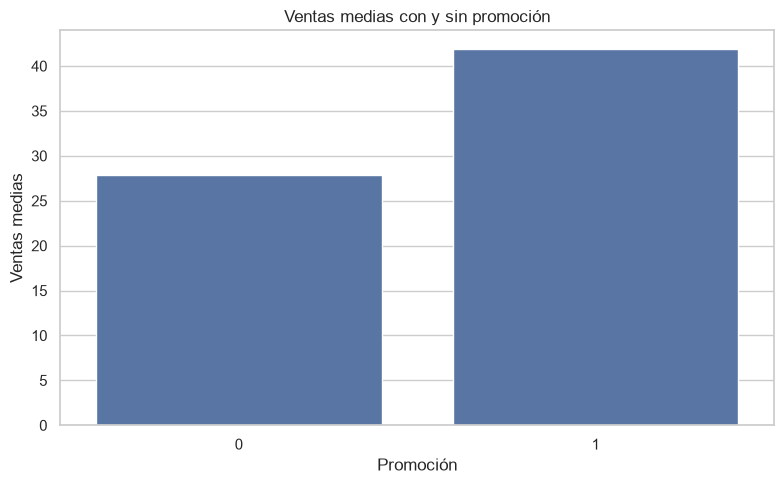

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=promo_sales, x="promo", y="avg_sales")
plt.title("Ventas medias con y sin promoción")
plt.xlabel("Promoción")
plt.ylabel("Ventas medias")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/ventas_medias_promocion.png", dpi=150)
plt.show()

## 12. Impacto de promociones por tienda

In [27]:
store_promo_impact = (
    df.groupby(["store_id", "promo"], as_index=False)
      .agg(avg_sales=("sales", "mean"))
)

store_promo_pivot = store_promo_impact.pivot(index="store_id", columns="promo", values="avg_sales")
store_promo_pivot.columns = ["avg_sales_no_promo", "avg_sales_promo"] if len(store_promo_pivot.columns) == 2 else store_promo_pivot.columns

if {"avg_sales_no_promo", "avg_sales_promo"}.issubset(store_promo_pivot.columns):
    store_promo_pivot["promo_lift_pct"] = (
        (store_promo_pivot["avg_sales_promo"] - store_promo_pivot["avg_sales_no_promo"]) 
        / store_promo_pivot["avg_sales_no_promo"] * 100
    )
    display(store_promo_pivot.sort_values("promo_lift_pct", ascending=False).head(15))
else:
    display(store_promo_pivot.head())

,avg_sales_no_promo,avg_sales_promo,promo_lift_pct
store_id,,,
store_17,26.19,40.00,52.72
store_20,26.08,39.70,52.24
store_4,29.57,44.96,52.04
store_1,27.02,40.92,51.43
store_27,25.04,37.87,51.28
store_37,26.24,39.68,51.24
store_18,28.76,43.48,51.21
store_38,23.89,36.11,51.19
store_16,24.86,37.57,51.15


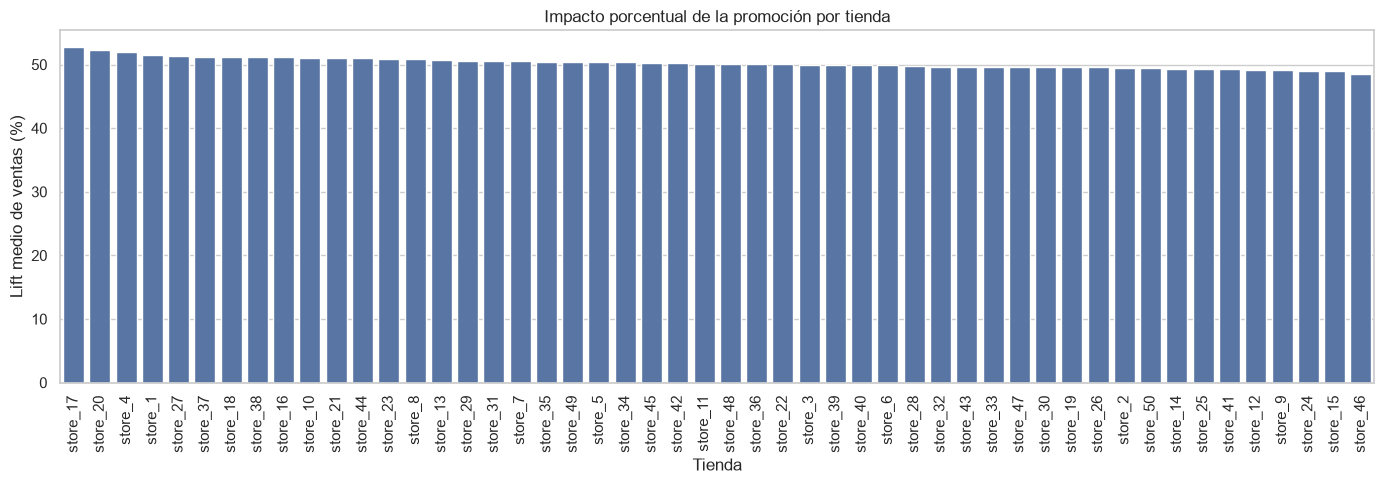

In [28]:
if "promo_lift_pct" in store_promo_pivot.columns:
    promo_lift_store = store_promo_pivot.reset_index().sort_values("promo_lift_pct", ascending=False)

    plt.figure(figsize=(14, 5))
    sns.barplot(data=promo_lift_store, x="store_id", y="promo_lift_pct")
    plt.title("Impacto porcentual de la promoción por tienda")
    plt.xlabel("Tienda")
    plt.ylabel("Lift medio de ventas (%)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_PATH}/impacto_promocion_por_tienda.png", dpi=150)
    plt.show()

## 13. Impacto de promociones por producto

In [29]:
item_promo_impact = (
    df.groupby(["item_id", "promo"], as_index=False)
      .agg(avg_sales=("sales", "mean"))
)

item_promo_pivot = item_promo_impact.pivot(index="item_id", columns="promo", values="avg_sales")
item_promo_pivot.columns = ["avg_sales_no_promo", "avg_sales_promo"] if len(item_promo_pivot.columns) == 2 else item_promo_pivot.columns

if {"avg_sales_no_promo", "avg_sales_promo"}.issubset(item_promo_pivot.columns):
    item_promo_pivot["promo_lift_pct"] = (
        (item_promo_pivot["avg_sales_promo"] - item_promo_pivot["avg_sales_no_promo"]) 
        / item_promo_pivot["avg_sales_no_promo"] * 100
    )
    display(item_promo_pivot.sort_values("promo_lift_pct", ascending=False).head(20))
else:
    display(item_promo_pivot.head())

,avg_sales_no_promo,avg_sales_promo,promo_lift_pct
item_id,,,
item_38,32.66,49.28,50.90
item_43,36.81,55.52,50.83
item_12,20.34,30.68,50.80
item_3,42.82,64.56,50.77
item_26,35.75,53.89,50.77
item_25,35.01,52.76,50.70
item_17,15.95,24.01,50.55
item_19,13.72,20.64,50.48
item_29,23.27,35.02,50.47


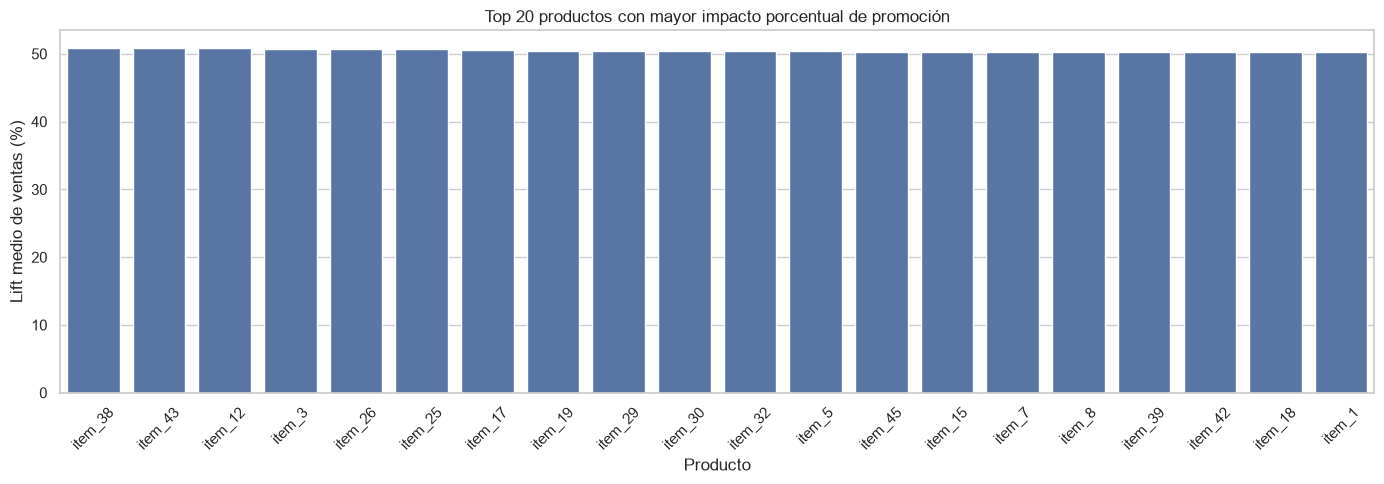

In [30]:
if "promo_lift_pct" in item_promo_pivot.columns:
    promo_lift_item = item_promo_pivot.reset_index().sort_values("promo_lift_pct", ascending=False)

    plt.figure(figsize=(14, 5))
    sns.barplot(data=promo_lift_item.head(20), x="item_id", y="promo_lift_pct")
    plt.title("Top 20 productos con mayor impacto porcentual de promoción")
    plt.xlabel("Producto")
    plt.ylabel("Lift medio de ventas (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_PATH}/impacto_promocion_por_producto.png", dpi=150)
    plt.show()

### Explicación

No todas las tiendas ni todos los productos responden igual a una promoción.  
Esta diferencia justifica incluir variables como `promo`, `store_id`, `item_id` o agregados históricos en fases posteriores del proyecto.


## 14. Variabilidad de demanda

In [31]:
demand_variability = (
    df.groupby(["store_id", "item_id"], as_index=False)
      .agg(
          avg_sales=("sales", "mean"),
          std_sales=("sales", "std"),
          total_sales=("sales", "sum"),
          observations=("sales", "count")
      )
)

demand_variability["cv_sales"] = demand_variability["std_sales"] / demand_variability["avg_sales"]
demand_variability = demand_variability.replace([np.inf, -np.inf], np.nan)

demand_variability.sort_values("cv_sales", ascending=False).head(20)

,store_id,item_id,avg_sales,std_sales,total_sales,observations,cv_sales
1865,store_43,item_23,9.98,4.29,18229,1826,0.43
1315,store_33,item_23,10.16,4.36,18544,1826,0.43
2215,store_5,item_23,10.48,4.43,19132,1826,0.42
1565,store_38,item_23,10.21,4.32,18640,1826,0.42
2365,store_7,item_23,10.06,4.24,18362,1826,0.42
1165,store_30,item_23,10.06,4.24,18378,1826,0.42
115,store_11,item_23,9.78,4.12,17856,1826,0.42
715,store_22,item_23,10.48,4.39,19135,1826,0.42
1765,store_41,item_23,10.41,4.35,19000,1826,0.42
2393,store_7,item_49,10.67,4.45,19490,1826,0.42


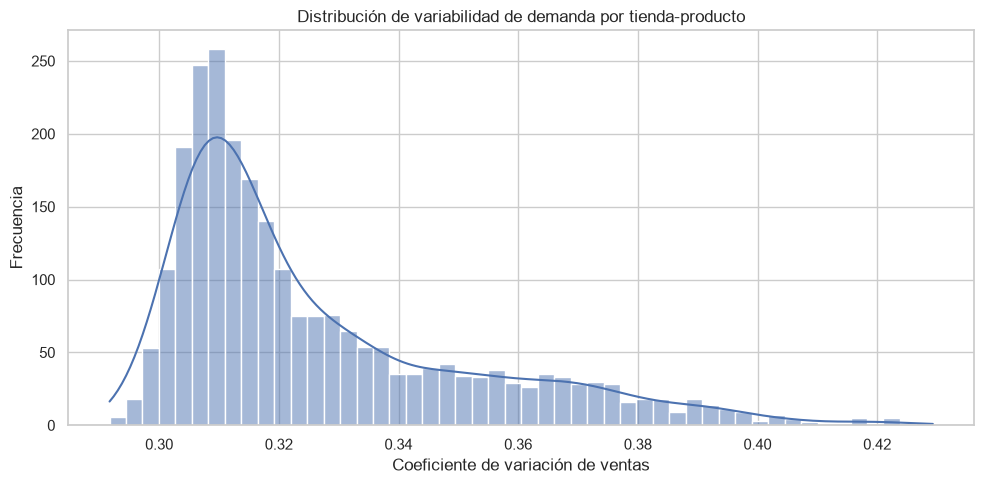

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(demand_variability["cv_sales"].dropna(), bins=50, kde=True)
plt.title("Distribución de variabilidad de demanda por tienda-producto")
plt.xlabel("Coeficiente de variación de ventas")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/variabilidad_demanda_cv.png", dpi=150)
plt.show()

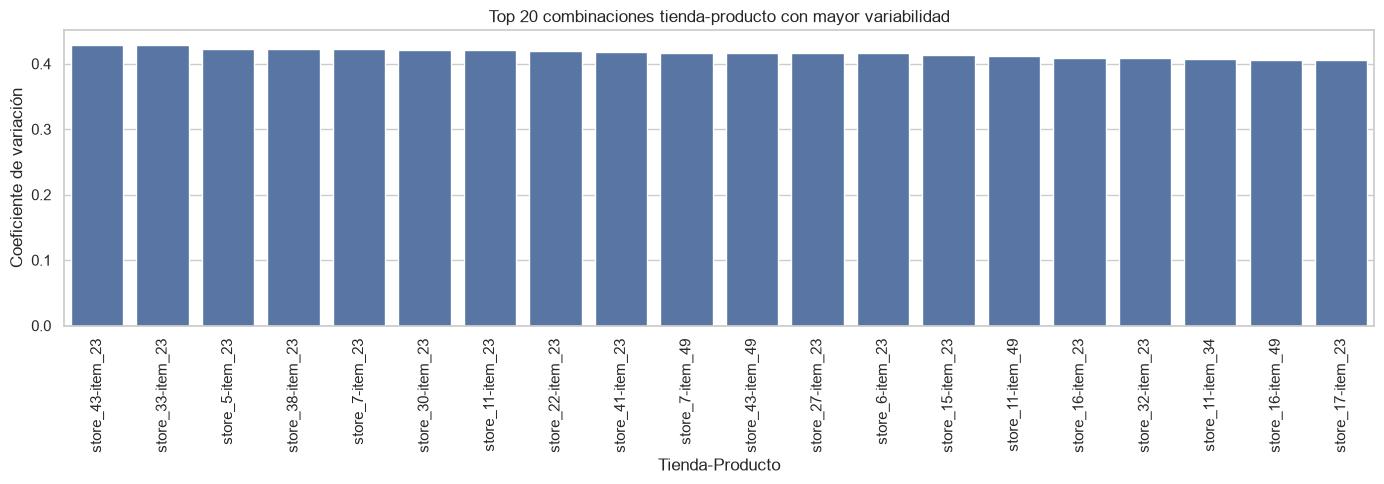

In [33]:
high_variability = demand_variability.sort_values("cv_sales", ascending=False).head(20)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=high_variability,
    x=high_variability["store_id"].astype(str) + "-" + high_variability["item_id"].astype(str),
    y="cv_sales"
)
plt.title("Top 20 combinaciones tienda-producto con mayor variabilidad")
plt.xlabel("Tienda-Producto")
plt.ylabel("Coeficiente de variación")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/top20_variabilidad_tienda_producto.png", dpi=150)
plt.show()

### Explicación

La variabilidad de demanda es clave para un problema de stockout.  
Una combinación tienda-producto con ventas medias moderadas pero alta variabilidad puede ser más difícil de gestionar que un producto con demanda estable.

## 15. Posibles patrones estacionales

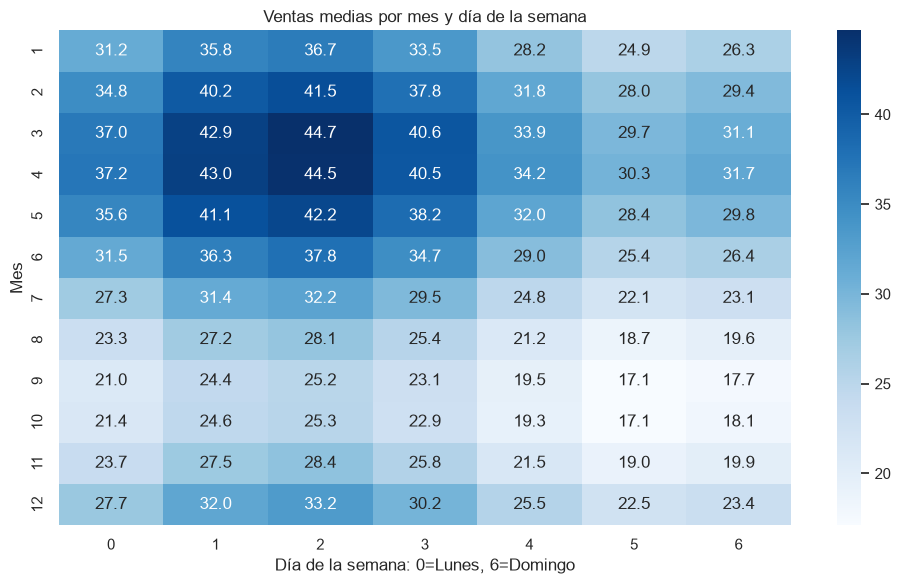

In [34]:
seasonality_month_weekday = (
    df.groupby(["month", "weekday"], as_index=False)
      .agg(avg_sales=("sales", "mean"))
)

seasonality_pivot = seasonality_month_weekday.pivot(index="month", columns="weekday", values="avg_sales")

plt.figure(figsize=(10, 6))
sns.heatmap(seasonality_pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Ventas medias por mes y día de la semana")
plt.xlabel("Día de la semana: 0=Lunes, 6=Domingo")
plt.ylabel("Mes")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/heatmap_estacionalidad_mes_dia_semana.png", dpi=150)
plt.show()

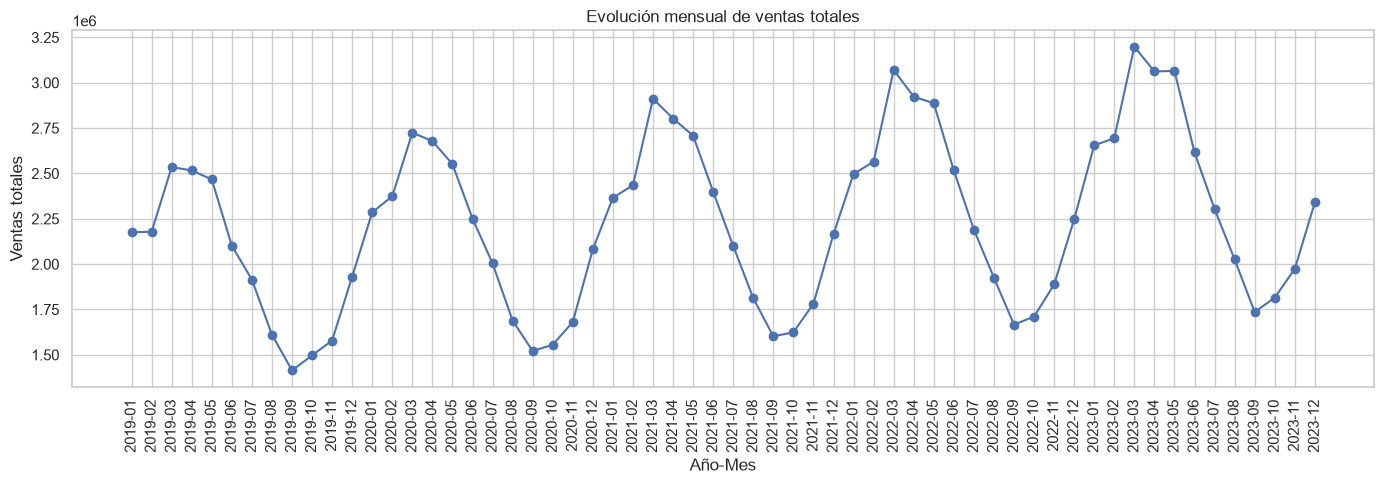

In [35]:
monthly_evolution = (
    df.groupby("year_month", as_index=False)
      .agg(total_sales=("sales", "sum"), avg_sales=("sales", "mean"))
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_evolution["year_month"], monthly_evolution["total_sales"], marker="o")
plt.title("Evolución mensual de ventas totales")
plt.xlabel("Año-Mes")
plt.ylabel("Ventas totales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/evolucion_mensual_ventas.png", dpi=150)
plt.show()

### Explicación

El mapa de calor permite identificar combinaciones de mes y día de la semana con mayor demanda media.  
Estos patrones pueden justificar el uso de variables temporales y medias móviles en el modelo predictivo.

## 16. Relación entre ventas, precio y promoción

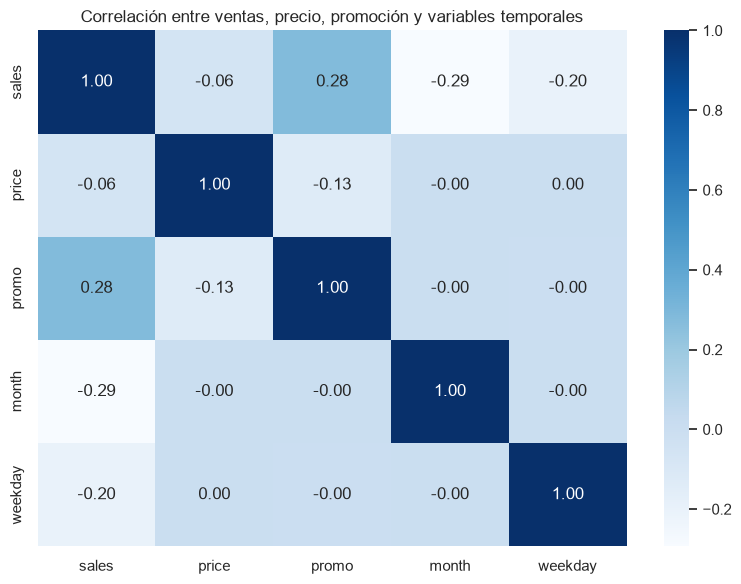

In [36]:
correlation_columns = ["sales", "price", "promo", "month", "weekday"]

corr = df[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlación entre ventas, precio, promoción y variables temporales")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/correlacion_ventas_precio_promocion.png", dpi=150)
plt.show()

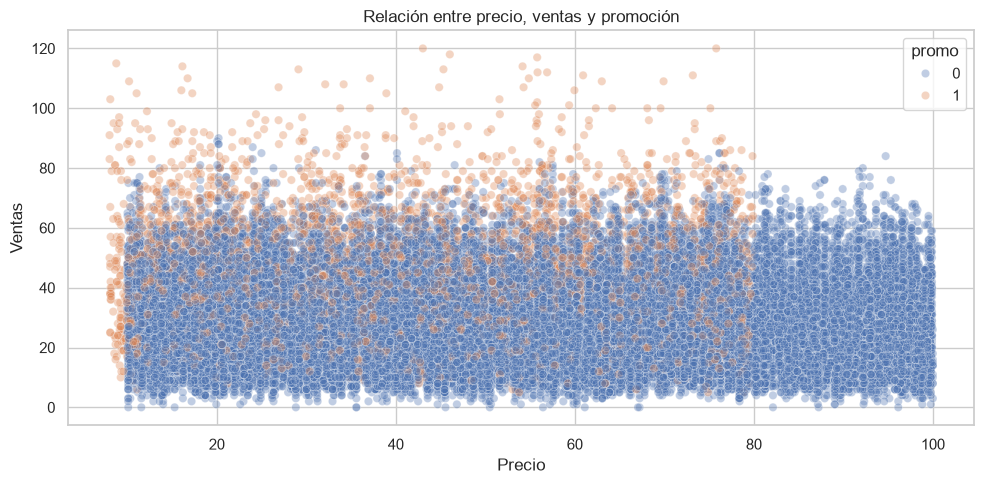

In [37]:
sample_df = df.sample(min(50_000, len(df)), random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample_df, x="price", y="sales", hue="promo", alpha=0.35)
plt.title("Relación entre precio, ventas y promoción")
plt.xlabel("Precio")
plt.ylabel("Ventas")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/relacion_precio_ventas_promocion.png", dpi=150)
plt.show()

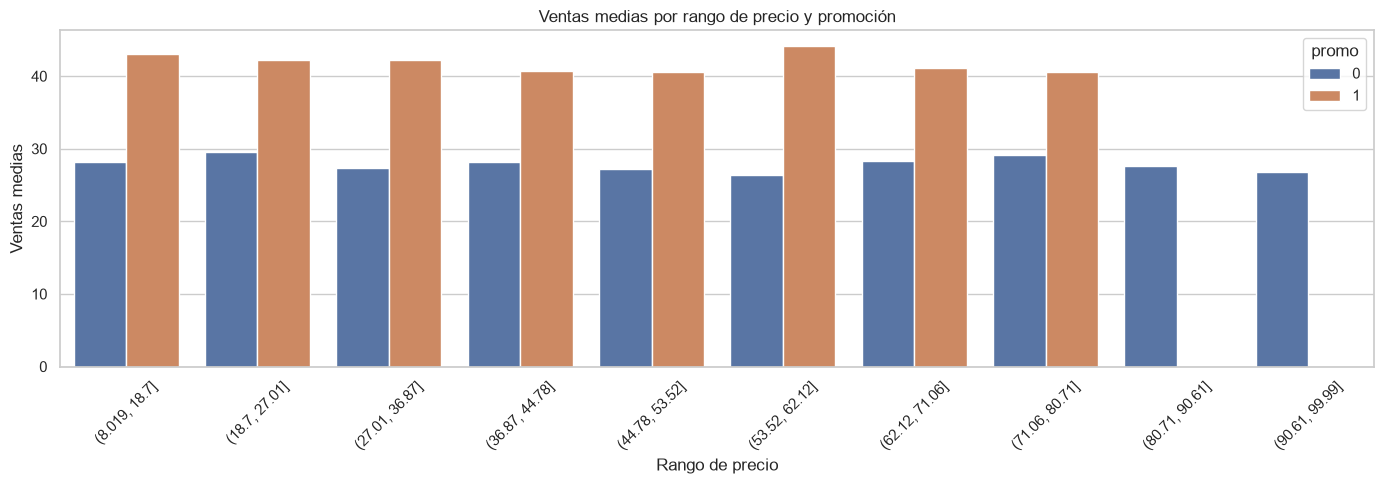

In [38]:
price_bins = pd.qcut(df["price"], q=10, duplicates="drop")

price_sales = (
    df.assign(price_bin=price_bins)
      .groupby(["price_bin", "promo"], as_index=False)
      .agg(avg_sales=("sales", "mean"), observations=("sales", "count"))
)

plt.figure(figsize=(14, 5))
sns.barplot(data=price_sales, x="price_bin", y="avg_sales", hue="promo")
plt.title("Ventas medias por rango de precio y promoción")
plt.xlabel("Rango de precio")
plt.ylabel("Ventas medias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/ventas_por_rango_precio_promocion.png", dpi=150)
plt.show()

### Explicación

Este análisis permite observar si la demanda varía en función del precio y si el efecto de la promoción cambia según el rango de precios.  
Para el modelo, esto justifica incluir precio, promoción y posibles variables derivadas como medias móviles o tendencias recientes.

## 17. Resumen de insights del EDA

In [39]:
summary_eda = {
    "rows": len(df),
    "columns": df.shape[1],
    "date_min": df["date"].min(),
    "date_max": df["date"].max(),
    "n_stores": df["store_id"].nunique(),
    "n_items": df["item_id"].nunique(),
    "total_sales": df["sales"].sum(),
    "avg_sales": df["sales"].mean(),
    "median_sales": df["sales"].median(),
    "avg_price": df["price"].mean(),
    "promo_rate": df["promo"].mean()
}

pd.Series(summary_eda)

rows                        4565000
columns                          12
date_min        2019-01-01 00:00:00
date_max        2023-12-31 00:00:00
n_stores                         50
n_items                          50
total_sales               133593174
avg_sales                     29.26
median_sales                  27.00
avg_price                     53.99
promo_rate                     0.10
dtype: object

## 18. Conclusiones para el modelado

A partir del análisis exploratorio, se extraen las siguientes conclusiones preliminares para el proyecto:

1. Las ventas presentan una evolución temporal que debe ser tenida en cuenta en el modelado.
2. Existen patrones por mes y por día de la semana, por lo que las variables temporales pueden aportar información útil.
3. La demanda varía de forma relevante entre productos y entre combinaciones tienda-producto.
4. Las promociones tienen impacto en las ventas, aunque dicho impacto puede variar según tienda y producto.
5. La variabilidad de demanda es un factor relevante para anticipar riesgo de rotura de stock.
6. La relación entre ventas, precio y promoción justifica incluir estas variables en el modelo, junto con variables históricas como lags, medias móviles y tendencias.
